# HW3: Building an AI Game Master (100pts)

*Credits to Original Author: Andrew Zhu (andrz@seas.upenn.edu)*

In this homework, we'll use Kani to build a simple Game Master (GM) for the [Mausritter TTRPG](https://losing-games.itch.io/mausritter). Your GM will help walk you through creating a mouse and rolling dice to overcome challenges in the game. Along the way, you'll learn the basics of the [Kani library](https://kani.readthedocs.io/en/latest/), function calling with LLMs, and how a LLM can use structured information to act as a game state manager.

We won't implement more complex systems like combat or spellcasting in this homework, but extending this system to make a more comprehensive GM (e.g. adding inventory tracking, combat, spellcasting, structured tracking of NPCs, ...) would make for a great class final project.

## What You'll Need

- A copy of the [Mausritter rules](https://losing-games.itch.io/mausritter) (available for free on itch.io)
- Your Triton AI API Key (or [Open AI API key](https://platform.openai.com/api-keys) if you have one)
- Recommended: the [Kani documentation](https://kani.readthedocs.io/en/latest/)
- Optional: the [d20 documentation](https://d20.readthedocs.io/en/latest/start.html)

# Part 0: Setup

*Reference: [Installation (Kani Documentation)](https://kani.readthedocs.io/en/latest/install.html)*

First, install the libraries we're using and configure Kani to use the Triton AI proxy (cells below). Kani requires Python 3.10 or higher—if you encounter an error saying "No matching distribution found", you may need to upgrade your Python version.

## Google Colab (easiest)

The simplest way to run this homework is [Google Colab](https://colab.research.google.com/): upload this notebook (**File → Upload notebook**) or open it from the course repository, then run the cells in order. Colab gives you a managed Python 3.10+ environment with nothing to install on your laptop.

1. Run the **Install dependencies** cell below (`pip install …`).
2. Set your API key: in Colab, open **Secrets** (key icon in the left sidebar), add a secret named `OPENAI_API_KEY` with your Triton or OpenAI key, enable **Notebook access**, then run this once **before** the engine setup cell:

```python
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
```

If you are not using Colab, set `OPENAI_API_KEY` on your machine as described under **Running locally** below.

## Running locally (optional)

If you prefer to run on your own computer, use a **virtual environment** so packages stay isolated.

Mac/Linux:
```shell
python3.10 -m venv ./venv
source ./venv/bin/activate
pip install jupyter
```

Windows:
```shell
python3.10 -m venv venv
venv\Scripts\activate.bat
pip install jupyter
```

You may need to restart your IDE after creating a new virtual environment for it to detect the interpreter. When the venv is active, run the same `pip install` command as in the cell below (or install `d20`, `kani[openai]`, and `openai` yourself).

### Line wrapping (VS Code)

If you use VS Code locally, you may want **Notebook Output Word Wrap** so long outputs fold to multiple lines: gear icon on the notebook → **Customize Notebook Layout** → enable **Notebook Output Word Wrap**.

In [ ]:
# Install dependencies
!pip install -q d20 'kani[openai]' openai

zsh:1: command not found: python3.10
zsh:source:1: no such file or directory: venv/bin/activate

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


We'll use `api-gpt-oss-120b` as our LLM of choice (feel free to try better models if your budget allows), so we'll configure it as our *engine* (a Kani concept used to provide a standard interface to an LLM).

<div>
<img src="https://kani.readthedocs.io/en/latest/_images/concepts-figure.png" width="700"/>
</div>

If you use **Google Colab**, set `OPENAI_API_KEY` with **Secrets** as in Part 0 (or export it in a cell) so the next code cell can read `os.environ["OPENAI_API_KEY"]`.

If you run **locally**, set your API key (Triton AI or OpenAI) in the environment before starting Jupyter or VS Code—for example in the terminal:

```
export OPENAI_API_KEY=sk-helicone-cp-###########
```

With VS Code, you can launch it from the terminal and pass the key on the same line:

```
cd your/homework/dir
source venv/bin/activate
OPENAI_API_KEY=sk-helicone-cp-###########  code .
```

We'll use the `engine` global throughout the rest of this homework.

In [1]:
# Set up an engine using the Triton AI API with custom client
from kani.engines.openai import OpenAIEngine
from openai import AsyncOpenAI
import os

# Set your Triton API key as an environment variable
api_key = os.environ["OPENAI_API_KEY"]

# Create a custom OpenAI client explicitly configured for Triton API
custom_client = AsyncOpenAI(
    api_key=api_key,
    # base_url="https://tritonai-api.ucsd.edu"
)

# Pass the custom client to OpenAIEngine
engine = OpenAIEngine(client=custom_client, model="gpt-4.1-mini")


/var/folders/dx/h3r_sjnn0q76ys1q4dgl5fkm0000gn/T/ipykernel_5199/4025849995.py:16: UserWarning: The OpenAI API type for this model was not set, defaulting to 'chat_completions' for 'gpt-4.1-mini'. Please specify `api_type="chat_completions"` or `api_type="responses"` if this is incorrect.
  engine = OpenAIEngine(client=custom_client, model="gpt-4.1-mini")


In [2]:
from kani import Kani

test_ai = Kani(engine)
print(await test_ai.chat_round_str("Reply with exactly: OK"))

OK


# Part 1: Dice Rolling & Function Calling

First, let's get familiar with the libraries we're going to use. 

## 1.1: Dice Rolling

To implement dice rolling, we'll use `d20`, a Python dice library I wrote for D&D. This library parses RPG dice notation and rolls the specified dice. For this homework, we'll use its output as Markdown, but if you're interested in a deeper dive into the library, the output is a [structured eval tree](https://d20.readthedocs.io/en/latest/expression.html).

Mausritter uses standard RPG dice notation throughout.

For example:
- `d20` means: Roll a single 20-sided die
- `1d8` means: Roll a single 8-sided die
- `3d6` means: Roll three 6-sided dice, add them together

In certain circumstances, you'll need to roll some dice and keep only the N highest (e.g. 4d6, keep highest 3). `d20` expresses this in "keep-highest" notation:

- `4d6kh3` means: Roll four six-sided dice, add the highest three together
- `2d20kl1` means: Roll two d20s, keep the lower ("disadvantage" in D&D, "advantage" in Mausritter)

For more examples, check out [the documentation](https://d20.readthedocs.io/en/latest/start.html#examples). Try running this cell a couple times to see what the result of these rolls are! Feel free to add more rolls to experiment, too.

In [3]:
from d20 import roll

print(roll("d20"))
print(roll("1d8"))
print(roll("3d6"))
print(roll("4d6kh3"))
print(roll("2d20kl1"))

1d20 (5) = `5`
1d8 (**8**) = `8`
3d6 (3, 4, 5) = `12`
4d6kh3 (**6**, **6**, ~~3~~, **6**) = `18`
2d20kl1 (~~13~~, 6) = `6`


In [4]:
# d20 can also handle basic math:
print(roll("2d6 * 3"))
print(roll("1d6 * 10 + 1d6"))

2d6 (2, 5) * 3 = `21`
1d6 (2) * 10 + 1d6 (**6**) = `26`


The `roll()` function returns a `RollResult` object, which contains the stringified roll (`RollResult.result`), its numeric total (`RollResult.total`), and the eval tree. You can use this, for example, to roll stats for a mouse!

Mausritter defines your mouse's stats as such:

> For each attribute, in order, roll 3d6. Keep the two highest dice results for a value between 2—12.

To make sure you understand how to use d20, let's this into a roll statement for one attribute, and print the result and final rolled total here.

In [5]:
# TODO: roll one attribute and print its roll and value
attr_result = roll("3d6kh2")
print(attr_result.result)
print(attr_result.total)

3d6kh2 (5, ~~4~~, **6**) = `11`
11


## 1.2: Function Calling

*Reference: [Function Calling (Kani Documentation)](https://kani.readthedocs.io/en/latest/function_calling.html)*

Now, let's give a LLM the ability to roll dice! With Kani, you can write functions in Python and expose them to the model with just one line of code: the `@ai_function` decorator.

To create a kani with function calling, make a subclass of Kani and write your functions as methods. In order for a language model to effectively know what our AI functions do, we need to document them. We do this inline in the function: through type annotations and the docstring.

The allowed types are:

- Python primitive types (`None`, `bool`, `str`, `int`, `float`)
- an enum (`enum.Enum`)
- a list or dict of the above types (e.g. `list[str]`, `dict[str, int]`, `list[SomeEnum]`)

When the AI calls into the function, kani validates the AI’s requested parameters and guarantees that the passed parameters are of the annotated type by the time they reach your code.

By default, the function’s description will be taken from its docstring, and name from the source.

To specify the descriptions of parameters, you can provide an AIParam annotation using a `typing.Annotated` type annotation.

For example, you might annotate a parameter `timezone: str` with an example, like `timezone: Annotated[str, AIParam("The IANA time zone, e.g. America/New_York")]`.

Let's use this to expose the `roll()` function to LLM. Your method should take in the dice as a string, and return the resulting Markdown roll to the model.

In [6]:
from kani import Kani, ai_function, ChatMessage, AIParam
from typing import Annotated

class DiceKani(Kani):
    @ai_function()
    def roll(
        self,
        # TODO: add a parameter to this method to tell the model what to pass to it
        dice: Annotated[str, AIParam(desc="Dice expression in RPG notation, e.g. d20, 1d8, 3d6, 4d6kh3 or 2d20kl1.")]
    ):
        """
        TODO: Add documentation to this method to tell the model how to use it
        HINT: Try giving the model examples, or telling it to use RPG notation
        """
        # TODO: roll the dice provided by the model and return the result to it
        result = roll(dice)
        return f"{result.result} = {result.total}"

Now, let's create an instance of your Kani with dice rolling and ask it to roll dice. In addition to standard queries like "roll me 4d6," an LLM can translate more complex queries from natural language to RPG dice syntax. Try asking it to roll an attribute for a mouse using Mausritter's natural language description, or even something that relies on background knowledge, like damage for a fireball spell.

To exit the chat session, send the word `!stop`.

In [7]:
from kani import chat_in_terminal

dice_ai = DiceKani(engine)
chat_in_terminal(dice_ai, stopword="!stop", verbose=True)

USER: roll me 4d6
AI: Thinking... [roll(dice='4d6')]
FUNC: 4d6 (4, 5, 4, 4) = `17` = 17
AI: You rolled 4d6 and got the results 4, 5, 4, and 4, which sums up to 17.


Easy, right? You can add more functions easily by defining more methods in your Kani subclass, and implement complex logic in the function body too. Let's use this to do something a little more complex: creating a character.

**NOTE**: if the `chat_in_terminal` function doesn't work on your notebook environment, you can try:
- 1) convert your notebook into python script and run the python script on your "terminal". (command for converting: `jupyter nbconvert --to python your_notebook.ipynb`)

or 

- 2) configure the engine with OpenAI's `AsyncOpenAI` client instead of the synchronous `OpenAI` client. Kani's `OpenAIEngine` accepts an async client, which often works better in Jupyter and other environments where an asyncio event loop is already running. For example, in your setup cell:

```python
from kani.engines.openai import OpenAIEngine
from openai import AsyncOpenAI
import os

api_key = os.environ["OPENAI_API_KEY"]

custom_client = AsyncOpenAI(
    api_key=api_key,
    base_url="https://tritonai-api.ucsd.edu"
)

engine = OpenAIEngine(client=custom_client, model="api-gpt-oss-120b")
```


# Part 2: Character Creation

*Reference: Mausritter rulebook, pg. 8; [Function Calling (Kani Documentation)](https://kani.readthedocs.io/en/latest/function_calling.html)*

Before we get started playing Mausritter, you need to make a mouse! Luckily, making a mouse is easy: just roll for stats, background, and details. We'll record the equipment your mouse starts with in this homework, but won't implement a full structured inventory system (unless you are doing an extension).

## 2.1: Character Creator Agent

Let's build an AI agent to help walk us through character creation. Since character creation is fairly algorithmic, it's possible to write a character generator (like the one at https://mausritter.com/mouse/) without the use of an LLM at all - but in this homework, we'll use LLM to parse the rules and output a mouse, ready to go.

First, let's define the goal: your agent should output a `Mouse` as defined here. Each of the structured character attributes matches those defined in the Mausritter rules, and we'll also add a LLM-generated prose description of your mouse.


In [8]:
import dataclasses
from dataclasses import dataclass


@dataclass
class Mouse:
    # structured character attributes
    strength: int
    dexterity: int
    will: int
    hp: int
    pips: int
    background: str
    birthsign: str
    disposition: str
    coat: str
    physical_detail: str
    name: str

    # LLM-generated
    description: str = ""


# Here's an example Mouse:
horatio = Mouse(
    name="Horatio Seedfall",
    background="Ale brewer",
    strength=11,
    dexterity=10,
    will=8,
    hp=2,
    birthsign="Wheel",
    disposition="Industrious / Unimaginative",
    coat="Chocolate, flecked",
    physical_detail="Tiny body",
    pips=3,
    description=(
        'Horatio Seedfall, more commonly known as "Ale Brewer" in his local mouse village, is a pint-sized powerhouse.'
        " His fur, a rich chocolate hue speckled with an array of lighter flecks, is reminiscent of the fine, roasted"
        " barley he uses in his brewing. His small size might deceive the unassuming observer, but beneath that tiny"
        " body of his lies a heart as tenacious as a bear's."
    ),
)

Now, we'll define a subclass of the `DiceKani` we made in part 1. This means that this Kani will also have access to roll dice!

You have a lot of freedom on how to implement the mouse creator here. Maybe you'll add functions to roll on each of the tables in the rulebook? Maybe you'll generate your mouse's background and other story attributes using the tables only for inspiration? Maybe you'll be able to simply prompt LLM with the mouse creation instructions?

Remember, we aren't tracking inventory in this homework in the structured JSON (unless you are doing an extension), so you don't need to generate structured data regarding items. **You should have the LLM write down what items come with your mouse's background in their prose description, though.**

Regardless of the approach you choose, your Kani should call the provided `make_mouse` function at least once. This function shows how you can use function calling to make LLM output a fairly large amount of structured data by presenting the desired data format as function parameters.

In [9]:
class MouseCreatorKani(DiceKani):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.mouse = None

    # TODO: add additional ai_functions here if needed
    # e.g. roll_attribute, lookup_background, roll_birthsign, generate_description, etc.
    @ai_function()
    def roll_attribute(self, stat_name: Annotated[str, AIParam(desc="The stat being rolled: strength, dexterity, or will.")]) -> str:
        """Roll one Mausritter attribute: 3d6, keep the two highest dice."""
        result = roll("3d6kh2")
        return f"{stat_name}: {result.result} = {result.total}"

    @ai_function()
    def roll_hp(self) -> str:
        """Roll starting HP for a Mausritter mouse."""
        result = roll("1d6")
        return f"HP: {result.result} = {result.total}"

    @ai_function()
    def roll_pips(self) -> str:
        """Roll visible pips/spots for the mouse."""
        result = roll("1d6")
        return f"Pips: {result.result} = {result.total}"

    # your Kani should call this at least once and output a valid mouse!
    # this parses the parameters LLM generates and passes them to the Mouse constructor,
    # then saves them to an instance attribute so we can use the created Mouse later
    @ai_function()
    def make_mouse(
        self,
        # TODO: Modify the types of the parameters of this method to add model prompting if needed
        strength: Annotated[int, AIParam(desc="Mouse STR, usually rolled with 3d6kh2.")],
        dexterity: Annotated[int, AIParam(desc="Mouse DEX, usually rolled with 3d6kh2.")],
        will: Annotated[int, AIParam(desc="Mouse WIL, usually rolled with 3d6kh2.")],
        hp: Annotated[int, AIParam(desc="Starting hit protection, usually 1d6.")],
        pips: Annotated[int, AIParam(desc="Number of visible pips or spots.")],
        background: str,
        birthsign: str,
        disposition: str,
        coat: str,
        physical_detail: str,
        name: str,
        description: str,
    ):
        """
        Create or update the player's Mausritter mouse. Call this only after all required fields are known.
        """
        self.mouse = Mouse(
            strength=strength,
            dexterity=dexterity,
            will=will,
            hp=hp,
            pips=pips,
            background=background,
            birthsign=birthsign,
            disposition=disposition,
            coat=coat,
            physical_detail=physical_detail,
            name=name,
            description=description,
        )
        # TODO: Tell LLM that you successfully created or updated the mouse
        return f"Successfully created mouse: {self.mouse.name}. The structured character sheet is saved."

You can add additional prompting here to tell the agent how to use your provided functions (e.g. a high-level flow).

In [10]:
# TODO: instruct LLM on how to call the functions you provided to it to create a mouse.
# Not sure where to start? Try giving it the whole mouse creation rules
MOUSE_CREATOR_PROMPT = """
You are a helpful Mausritter character creation assistant.

Guide the player step by step through creating one mouse character.
Use the provided tools whenever dice are needed:
- roll_attribute for STR, DEX, and WIL
- roll_hp for starting HP
- roll_pips for pips/spots
- roll for any other Mausritter table roll or dice expression

Do not invent dice results. If a value should be random, call a tool first.

You must eventually call make_mouse exactly when you have:
strength, dexterity, will, hp, pips, background, birthsign, disposition, coat,
physical_detail, name, and description.

The description should be flavorful prose and should mention the mouse's background and starting items/equipment in natural language.
"""

Finally, chat with your agent and make a mouse! We'll use your mouse in the last part to play a small game of Mausritter.

In [11]:
# Run this cell to reset the state of your mouse creator
mouse_creator_ai = MouseCreatorKani(engine, always_included_messages=[ChatMessage.user(MOUSE_CREATOR_PROMPT)])

In [12]:
def message_text(msg):
    """Best-effort readable text for Kani ChatMessage objects."""
    role = getattr(msg, "role", "unknown")
    role = getattr(role, "value", str(role))

    text = getattr(msg, "text", None)
    if text:
        return f"{role.upper()}: {text}"

    content = getattr(msg, "content", None)
    if content:
        return f"{role.upper()}: {content}"

    return f"{role.upper()}: {msg}"


def save_transcript(ai, filename):
    with open(filename, "w", encoding="utf-8") as f:
        for msg in ai.chat_history:
            f.write(message_text(msg))
            f.write("\n\n")
    print(f"Saved transcript to {filename}")

In [14]:
import time

# You can rerun this cell to continue conversation with your mouse creator
# Send "!stop" when you are done making your mouse
chat_in_terminal(mouse_creator_ai, stopword="!stop", verbose=True)
mouse_creator_ai.save(f"creator-{int(time.time())}.json")
save_transcript(mouse_creator_ai, "create_character.txt")

USER: 
AI: If you have any more questions or need help with your Mausritter adventures, feel free to ask. Have fun with Yang!
Saved transcript to create_character.txt


Let's retrieve your mouse and print them here, to make sure everything saved correctly. Let's also save it to a JSON file in case you rerun this notebook and want to continue from here.

In [15]:
import json

my_mouse = mouse_creator_ai.mouse
mouse_dict = dataclasses.asdict(my_mouse)

with open("my-character.json", "w") as f:
    json.dump(mouse_dict, f, indent=2)

mouse_dict

{'strength': 11,
 'dexterity': 11,
 'will': 8,
 'hp': 3,
 'pips': 2,
 'background': 'Exiled',
 'birthsign': 'The Hawk',
 'disposition': 'Brave',
 'coat': 'White with brown patches',
 'physical_detail': 'One ear slightly bent and bright green eyes',
 'name': 'Yang',
 'description': 'Yang is a brave little mouse with a striking white coat adorned with brown patches. One ear is slightly bent, giving them a charming, rugged look, and their bright green eyes gleam with determination. As an Exiled, Yang carries the weight of a past marked by banishment but faces the future with courage and resolve. With a starting set of basic adventuring gear, Yang is ready to face whatever dangers lie ahead in the wilds.'}

In [16]:
# To load a saved mouse, run this cell
with open("my-character.json") as f:
    mouse_dict = json.load(f)
my_mouse = Mouse(**mouse_dict)

If all goes well, you now have a mouse to play with! In the cell below, write down your high-level approach to the character creator -- e.g. did you give the model flexible control over the process or strict step-by-step instructions -- and any insights you learned while iterating on the agent.

Some things you could mention: Do you think a player who's never played a TTRPG before could create a mouse using your character creator by chatting with your agent and asking questions where they don't understand? How might you implement this agent in part of a larger system?

In the next part, we'll make a Kani that can roll checks and saves, and play a small game of Mausritter.

In [17]:
CHARACTER_CREATOR_INSIGHTS = """
TODO: Add your thoughts here
I used a hybrid approach: strict tool calls for dice-based values, and flexible language-model generation for names, description, and flavor.
This worked well because the numeric character sheet stayed grounded in real rolls, while the model could still make the character feel alive.

A new TTRPG player could probably use this creator because the agent explains each step conversationally. In my opinion, with the options for the
user the select from is also a plus since it would be easier to guide the user.
In a larger system, I would connect this character creator to persistent storage and a richer inventory tracker.
"""

## 2.2: Use Nano Banana/DALL-E to generate a character portrait

Now we've generated a structured representation of your mouse and a prose description of what they look like, but can we turn this collection of attributes into an image? Let's use Nano Banana or DALL-E 3 to generate a portrait of your mouse!

- For Nano Banana, you may have free access to Gemini Pro for a year, which includes Nano Banana (https://gemini.google.com/). Feel free to use the LLM-generated description or improve it with your own words. Download the generated image from Gemini and submit it to Gradescope. Skip the cell below for the DALL-E instructions.

- For DALL-E, you'll need to use your personal OpenAI account for DALL-E. It costs $0.04-$0.12 to generate one image with DALL-E 3, depending on the resolution and quality settings (https://openai.com/pricing). Run the next cell to set up your personal OpenAI API key and generate image with DALL-E. *Reference: [Images (OpenAI Documentation)](https://platform.openai.com/docs/api-reference/images)*

In [18]:
###############################
### DALL-E Image Generation ###
###############################

'''
This code cell defines what you'll need to call the DALL-E API.
It provides the `generate_image(prompt)` function which will call the Generate Image endpoint and download the generated image.

DALL-E 3 will also revise the prompt you provide to it by default, augmenting it with more synthetic details.
This can often help the model generate higher-fidelity images, but can also introduce weird hallucinations into the final image.
The `generate_image` function will print out both the original prompt and its revision as sent to the image generation model.
'''

import getpass
import httpx
from openai import OpenAI
import re
from IPython.display import Image, display

if "OPENAI_API_KEY" not in os.environ:
    print("You didn't set your OpenAI key to the OPENAI_API_KEY env var on the command line.")
    os.environ["OPENAI_API_KEY"] = getpass("Please enter your OpenAI API Key now: ")

    
# create the OpenAI client
dalle_client = OpenAI()
http = httpx.Client()

# make a folder to save generated images
os.makedirs("dalle", exist_ok=True)


def make_safe_filename(name, ext=".png"):
    """Ensure that a filename is safe to save to disk (replace any non-alphanumeric characters with an underscore)."""
    name = re.sub(r"[^a-zA-Z0-9-]+", "_", name)
    name = name[:100]
    return f"{name}{ext}"


def generate_image(prompt):
    """Generate an image, save it to disk, and display it.

    Returns a dict {"image_path": "...", "original_prompt": "...", "revised_prompt": "..."}.
    """

    # generate the image using the OpenAI API
    resp = dalle_client.images.generate(
        prompt=prompt,
        model="dall-e-3",
        response_format="url",
        quality="hd",  # feel free to change to "standard" for some cost savings
        size="1024x1024",  # also try "1024x1792" for portrait or "1792x1024" for landscape
        style="vivid",  # "vivid" or "natural"
    )
    image = resp.data[0]

    # download the generated image from URL (expires after 60m)
    fp = f"dalle/{make_safe_filename(image.revised_prompt)}"
    with open(fp, "wb") as f:
        with http.stream("GET", image.url) as r:
            for data in r.iter_bytes():
                f.write(data)

    # show the prompt, DALL-E rewrite, and the image
    print("Original prompt:", prompt)
    print()
    print("Revised prompt:", image.revised_prompt)
    print()
    print(f"Saved to {fp}")
    display(Image(fp, width=500, height=500))

    return {"image_path": fp, "original_prompt": prompt, "revised_prompt": image.revised_prompt}

In [19]:
import os, base64, re
from openai import OpenAI
from IPython.display import Image, display

image_client = OpenAI()
os.makedirs("dalle", exist_ok=True)

def make_safe_filename(name, ext=".png"):
    name = re.sub(r"[^a-zA-Z0-9-]+", "_", name)[:80]
    return f"{name}{ext}"

def generate_image(prompt):
    resp = image_client.images.generate(
        model="gpt-image-1",
        prompt=prompt,
        size="1024x1024",
    )
    image_bytes = base64.b64decode(resp.data[0].b64_json)
    fp = f"dalle/{make_safe_filename('character_portrait')}"
    with open(fp, "wb") as f:
        f.write(image_bytes)
    display(Image(fp, width=500, height=500))
    return {"image_path": fp, "original_prompt": prompt}

Now it's up to you to generate an image for your mouse you created in part 2.1. You could manually write a prompt, create a template based off the structured attributes you have available, or create a new Kani agent to write prompts for you! Whichever you choose, please describe your approach below.

Feel free to modify the commented parameters in the `dalle_client.images.generate` call above.

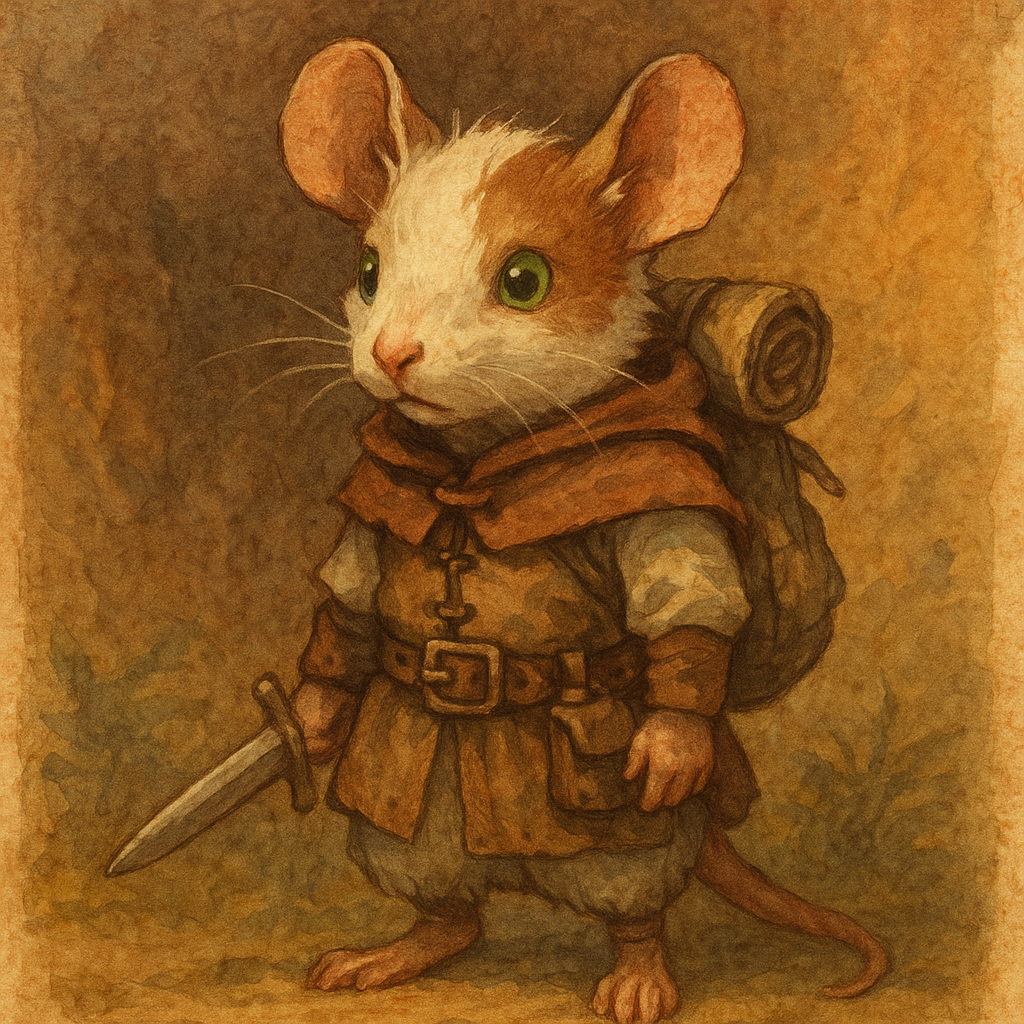

{'image_path': 'dalle/character_portrait.png',
 'original_prompt': '\nA fantasy storybook portrait of a Mausritter mouse adventurer named Yang.\nBackground: Exiled.\nCoat: White with brown patches.\nPhysical detail: One ear slightly bent and bright green eyes.\nDisposition: Brave.\nDescription: Yang is a brave little mouse with a striking white coat adorned with brown patches. One ear is slightly bent, giving them a charming, rugged look, and their bright green eyes gleam with determination. As an Exiled, Yang carries the weight of a past marked by banishment but faces the future with courage and resolve. With a starting set of basic adventuring gear, Yang is ready to face whatever dangers lie ahead in the wilds..\nSmall mouse scale, medieval mouse adventurer clothing, warm natural lighting, detailed but charming, no text.\n'}

In [20]:
# TODO: Use Nano Banana or DALL-E to create a portrait for your mouse. Submit your result image(s) directly to Gradescope.
portrait_prompt = f"""
A fantasy storybook portrait of a Mausritter mouse adventurer named {my_mouse.name}.
Background: {my_mouse.background}.
Coat: {my_mouse.coat}.
Physical detail: {my_mouse.physical_detail}.
Disposition: {my_mouse.disposition}.
Description: {my_mouse.description}.
Small mouse scale, medieval mouse adventurer clothing, warm natural lighting, detailed but charming, no text.
"""

image_info = generate_image(portrait_prompt)
image_info

In [21]:
# TODO: What approach did you use to create prompts for image generation? What strengths and weaknesses does this approach have? If you tried multiple approaches, how do they compare?
YOUR_IMAGE_GEN_APPROACHES = """
I generated the image prompt from the structured mouse sheet plus the prose description.
The strength of this approach is consistency: the image prompt uses the same background, coat, physical detail, and personality that were saved in the character.
The weakness is that some visual details are still interpreted creatively by the image model, so the final portrait may not match every detail exactly.
"""

# Part 3: Playing the Game

*Reference: Mausritter rulebook, pg. 12 & pg. 18*

Finally, let's make a GM Kani! If you're familiar with [AI Dungeon](https://aidungeon.com/), the concept here is similar: the model will act as our GM, defining the world and challenges in it. Unlike AI Dungeon, though, we have a character that we created and the ability to roll based off that character sheet!

Let's implement Saves (Mausritter p. 12):

> When you describe your mouse doing something risky where the outcome is uncertain and failure has consequences, the GM will ask you to make a save against either STR, DEX or WIL.
> To make a save, roll a d20. If the result is less than or equal to the relevant attribute, your mouse succeeds, and suffers no consequences. If the result is over the attribute, your mouse fails, and suffers the consequences described by the GM.

Again, we'll make a Kani that subclasses our DiceKani in part 1. You should implement the `roll_save` method that takes in the stat and if the roll is at advantage or disadvantage, and returns whether or not the save was successful.

In [22]:
class MausritterKani(DiceKani):
    # This Kani should reference your mouse - let's pass it in the constructor.
    def __init__(self, *args, mouse: Mouse, **kwargs):
        super().__init__(*args, **kwargs)
        self.mouse = mouse

    @ai_function()
    def roll_save(
        self,
        # TODO: add necessary parameters
        stat: Annotated[str, AIParam(desc="The save stat: STR, DEX, WIL, strength, dexterity, or will.")],
        advantage: Annotated[bool, AIParam(desc="True if the save has advantage. Advantage rolls 2d20 and keeps the lower result.")],
        disadvantage: Annotated[bool, AIParam(desc="True if the save has disadvantage. Disadvantage rolls 2d20 and keeps the higher result.")],
    ):
        """Roll a Mausritter save for the current mouse and report success or failure."""
        # TODO: roll a save for the given stat, compare it to your mouse's stats, and tell the LLM if you succeed or fail
        aliases = {
            "str": "strength",
            "strength": "strength",
            "dex": "dexterity",
            "dexterity": "dexterity",
            "wil": "will",
            "will": "will",
        }

        key = stat.lower().strip()
        if key not in aliases:
            return "Invalid save stat. Use STR, DEX, or WIL."

        attr = aliases[key]
        target = getattr(self.mouse, attr)

        if advantage and disadvantage:
            dice = "d20"
            mode = "normal, because advantage and disadvantage cancel"
        elif advantage:
            dice = "2d20kl1"
            mode = "advantage"
        elif disadvantage:
            dice = "2d20kh1"
            mode = "disadvantage"
        else:
            dice = "d20"
            mode = "normal"

        result = roll(dice)
        success = result.total <= target
        outcome = "SUCCESS" if success else "FAILURE"

        return f"{self.mouse.name} rolls a {attr.upper()} save with {mode}: {result.result} = {result.total}. Target: {target}. Outcome: {outcome}."


In [23]:
# TODO: instruct LLM on how to call the functions you provided to it and high-level instructions to run the game.
# You should also include information on the character you created so the GM can reference it.
# Not sure where to start? Try telling it to introduce the world first.
# You might also want to look at the play example on pg. 18 of the Mausritter rulebook.
GM_PROMPT = """
You are the Game Master for a short Mausritter adventure.

Use this character sheet:
{my_mouse}

Run the game conversationally. Start by introducing a small dangerous mouse-scale situation.
When the player attempts something risky with uncertain outcome and consequences, ask for a save:
- STR for force, endurance, or toughness
- DEX for speed, stealth, balance, or precision
- WIL for courage, focus, magic, or mental resistance

When a save is needed, call roll_save. Do not invent save results.
Use advantage only when circumstances clearly help the mouse.
Use disadvantage only when circumstances clearly hinder the mouse.

Keep scenes concise, describe consequences clearly, and ask the player what they do next.
"""

In [24]:
# Run this cell to reset the state of your game
# You can also add existing chat_history here if you'd like
gm_ai = MausritterKani(engine, mouse=my_mouse, system_prompt=GM_PROMPT)

Now, explore the world created by your model! When you're done, send `!stop`. The game transcript will be automatically saved to `gm.json`.

In [25]:
# You can rerun this cell to continue the game
# Send "!stop" when you are done making your mouse
chat_in_terminal(gm_ai, stopword="!stop", verbose=True)
gm_ai.save(f"gm-{int(time.time())}.json")
save_transcript(gm_ai, "game_play_structured.txt")

USER: hi
AI: Welcome to the world of Mausritter, brave mouse adventurer! You're a small mouse living in a big, dangerous world, full of perils and treasures.

Right now, you find yourself at the edge of a sunken wooden crate in the middle of an abandoned pantry. There's a faint buzzing sound nearby... a swarm of wasps has taken up residence. If you move too fast or make a loud noise, they might attack.

What do you do?
USER: try to escape
AI: You decide to carefully and quietly sneak away from the wasps' crate to avoid disturbing them.

To escape without provoking the wasps, you'll need to move swiftly and silently. I'll ask you to make a DEX save to see if you can slip away unseen and unheard.

Let's see how you do!
AI: Thinking... [roll_save(stat='DEX', advantage=False, disadvantage=False)]
FUNC: Yang rolls a DEXTERITY save with normal: 1d20 (2) = `2` = 2. Target: 11. Outcome: SUCCESS.
AI: You move with great care and speed, managing to slip away from the crate before the wasps even 

## Structureless Comparison

Cool, isn't it? But is it really *better* to provide LLMs with this structured information and access to tools?

To answer this question, let's try playing without structure: only prompt LLM to act as the GM WITHOUT access to your character sheet or dice rolling.

In [26]:
# TODO: instruct LLM on how to act as a Mausritter GM.
# You should NOT include information on function calling, but may tell it about your character (your choice).
GM_PROMPT_STRUCTURELESS = """
You are the Game Master for a short Mausritter adventure.

Run the game using only conversation. Do not call tools. Do not mention function calling.
You may refer to this character for flavor:
{my_mouse}

Introduce a small dangerous mouse-scale situation, describe the world vividly but concisely,
and ask the player what they do next. If a risky action happens, narrate an outcome yourself.
"""

In [27]:
# We'll use an unmodified Kani here -- it won't have access to dice rolling.
gm_ai_structureless = Kani(engine, system_prompt=GM_PROMPT_STRUCTURELESS)

In [28]:
# You can rerun this cell to continue the game
# Send "!stop" when you are done making your mouse
chat_in_terminal(gm_ai_structureless, stopword="!stop", verbose=True)
gm_ai_structureless.save(f"gm-structureless-{int(time.time())}.json")
save_transcript(gm_ai_structureless, "game_play_unstructured.txt")

USER: hi
AI: Greetings, brave mouse! You find yourself in the hushed underbrush of a sprawling garden, where dew glistens like diamonds on the tips of blades of grass. The scent of wildflowers mingles with the earth, and distant birdsong fills the air. Nearby, a cluster of mushrooms forms a natural shelter, but the faint scurrying sounds hint that you might not be alone.

Suddenly, a low rumble shakes the ground—it’s the dangerous passage of a curious mole, its snout inches from your hiding spot. You glimpse the glint of its sharp claws as it digs through the soil with relentless determination.

What do you do next?
USER: find weapon
AI: You quickly scan your surroundings, eyes darting over the tiny landscape that is your world. Near the base of a stalk, you spot a discarded, delicate thorn, curved and sharp—a perfect makeshift weapon for a brave mouse like yourself. Nearby, a small pebble might serve as a projectile if thrown with precision.

The mole continues its digging, unaware of

Did you notice any significant difference in the gameplay in the short term? How about in the long term? Why do you think this might be? Could you think of any other functions you could expose to the GM to improve its story coherence over multiple play sessions? Write down your thoughts here.

In [29]:
AI_GM_THOUGHTS = """
TODO: Write your thoughts here.
The structured GM felt more grounded because saves used the actual character stats and real dice rolls.
The structureless GM was smoother conversationally, but it was easier for it to invent outcomes or ignore the character sheet.

I think in the short term, both could create a fun scene; in the long term, the structured version should be more consistent because important state lives outside the
model.
Useful future tools would include inventory tracking, HP tracking, condition tracking, NPC memory, location notes, and a session summary function.
"""

That's it for HW3! Hopefully you've gained an understanding of how structured game state can influence LLMs, and how to use Kani with function calling to give LLMs powerful capabilities. These skills will come in handy as you begin working on your final projects!

## What to submit

Please submit the following:

- the notebook `hw3-aidm.ipynb` with all TODOs and free-response sections completed
- the latest saved transcripts of your character creator agent and gameplay (with a structured and unstructured AI GM)
  - create_character.txt
  - game_play_structured.txt
  - game_play_unstructured.txt
- the image(s) you generated of your character
  - character_portrait.png (or .jpg)

Note that Gradescope enforces these filenames strictly.